# simcausal many-mediators causal SHAP demo

This notebook reproduces the teaching demo for the ACIC 2026 causal SHAP poster. The data-generating process has upstream causes, many pathophysiologic mediators, and several downstream proxy measurements. The proxies are highly predictive, but they have no directed path into the outcome. That structure is designed to foil standard predictive SHAP and show what changes when the attribution procedure is supplied with causal knowledge.

## Demo logic

1. Generate a linear Gaussian DAG with `simcausal`.
2. Fit a flexible predictive model to all features.
3. Compute ordinary SHAP on the fitted model.
4. Compute DAG-constrained causal SHAP with the expert edge list.
5. Compare both rankings to analytic total effects from the known DAG.

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().resolve()
if ROOT.name == "demo":
    ROOT = ROOT.parent
DEMO = ROOT / "demo"
OUTPUT = DEMO / "output"
OUTPUT.mkdir(parents=True, exist_ok=True)

ROOT, DEMO, OUTPUT

(WindowsPath('C:/Users/wilso/OneDrive/Documents/GitHub/conference-materials/acic-2026-causal-shap'),
 WindowsPath('C:/Users/wilso/OneDrive/Documents/GitHub/conference-materials/acic-2026-causal-shap/demo'),
 WindowsPath('C:/Users/wilso/OneDrive/Documents/GitHub/conference-materials/acic-2026-causal-shap/demo/output'))

## 1. Generate the simcausal data

The R script saves the observed synthetic data, the expert edge list, node roles, and analytic total effects. The downstream proxy variables are descendants of the mediators and treatment workflow; they are predictive artifacts rather than causes of `AcuteRisk`.

In [2]:
subprocess.run(
    ["Rscript", str(DEMO / "simcausal_many_mediators.R"), "2500", "20260506", str(OUTPUT)],
    cwd=str(ROOT),
    check=True,
)

CompletedProcess(args=['Rscript', 'C:\\Users\\wilso\\OneDrive\\Documents\\GitHub\\conference-materials\\acic-2026-causal-shap\\demo\\simcausal_many_mediators.R', '2500', '20260506', 'C:\\Users\\wilso\\OneDrive\\Documents\\GitHub\\conference-materials\\acic-2026-causal-shap\\demo\\output'], returncode=0)

In [3]:
data = pd.read_csv(OUTPUT / "simcausal_many_mediators.csv")
roles = pd.read_csv(OUTPUT / "node_roles.csv")
truth = pd.read_csv(OUTPUT / "true_total_effects.csv")

print(data.shape)
display(data.head())
display(truth.head(10))

(2500, 19)


,Age,BaselineSeverity,ChronicBurden,SocialRisk,PracticeStyle,TreatmentIntensity,Inflammation,Coagulation,RenalStress,PerfusionDeficit,OxygenDeficit,Lactate,EndOrganStress,ShockIndexProxy,VasopressorProxy,MonitoringProxy,RescueProxy,CompositeScoreProxy,AcuteRisk
0,-0.503425,0.110177,1.260275,0.959457,0.282337,-0.308356,0.319104,0.803774,1.349209,1.205380,0.610963,0.637527,0.755838,1.974737,0.872378,1.970578,1.757984,2.059360,8.045321
1,0.409632,-0.384462,-0.553987,-0.577609,0.397798,-0.359565,0.351284,0.176005,-0.129203,-0.075232,0.294275,0.906003,1.505882,0.791006,-0.430162,1.012777,1.029517,1.243556,0.799053
2,0.204066,-1.665800,-0.062399,-0.942292,-0.992239,-1.496438,-1.387351,-0.514282,-0.389413,-1.806664,-0.513394,-1.240336,-0.915630,-2.385050,-2.954085,-1.704977,-3.336758,-2.706708,-5.727938
3,-0.370474,0.533100,-0.233844,0.062558,0.667253,-0.009941,0.580274,0.039380,0.850421,0.788355,-0.110428,0.749397,0.984007,1.762715,1.783399,1.059077,2.344278,2.358990,3.359983
4,0.106069,1.563146,1.999804,0.506348,0.306214,1.828920,1.786777,2.209268,2.477653,1.697934,1.267652,2.229612,2.217561,3.619650,3.587386,3.071050,4.710519,4.827068,11.751130


,feature,true_total_effect,true_abs_total_effect,role
0,BaselineSeverity,3.526670,3.526670,Root cause
1,Inflammation,2.766341,2.766341,Mediator
2,ChronicBurden,1.964635,1.964635,Root cause
3,TreatmentIntensity,-1.819909,1.819909,Treatment
4,PerfusionDeficit,1.702562,1.702562,Mediator
5,Lactate,0.895000,0.895000,Mediator
6,RenalStress,0.842500,0.842500,Mediator
7,PracticeStyle,-0.818959,0.818959,Root cause
8,OxygenDeficit,0.773750,0.773750,Mediator
9,Coagulation,0.677500,0.677500,Mediator


## 2. Run standard SHAP and causal SHAP

The Python runner imports the implementation in `app/causal_shap.py`. Causal SHAP is intentionally run with a modest number of topological permutations so the notebook remains teachable on a laptop. Increase `--n-perms`, `--n-background`, and `--n-instances` for a slower, smoother classroom run.

In [4]:
subprocess.run(
    [
        sys.executable,
        str(DEMO / "run_causal_shap_demo.py"),
        "--output-dir",
        str(OUTPUT),
        "--n-perms",
        "16",
        "--n-background",
        "8",
        "--n-instances",
        "12",
    ],
    cwd=str(ROOT),
    check=True,
)

CompletedProcess(args=['C:\\Users\\wilso\\AppData\\Local\\Programs\\Python\\Python313\\python.exe', 'C:\\Users\\wilso\\OneDrive\\Documents\\GitHub\\conference-materials\\acic-2026-causal-shap\\demo\\run_causal_shap_demo.py', '--output-dir', 'C:\\Users\\wilso\\OneDrive\\Documents\\GitHub\\conference-materials\\acic-2026-causal-shap\\demo\\output', '--n-perms', '16', '--n-background', '8', '--n-instances', '12'], returncode=0)

## 3. Inspect the recovery

In [5]:
summary = json.loads((OUTPUT / "demo_summary.json").read_text())
summary

{'seed': 20260506,
 'n_rows': 2500,
 'n_features': 18,
 'model': 'GradientBoostingRegressor',
 'test_r2': 0.9408009453009982,
 'test_mae': 0.9674035169051417,
 'n_perms': 16,
 'n_background': 8,
 'n_instances': 12,
 'kendall_tau_standard_vs_truth': 0.22310032643658012,
 'kendall_tau_causal_vs_truth': 0.4394400369205365,
 'spearman_r_standard_vs_truth': 0.27008767686943375,
 'spearman_r_causal_vs_truth': 0.5495606398076895,
 'mean_rank_error_standard': 4.333333333333333,
 'mean_rank_error_causal': 3.3333333333333335,
 'downstream_proxy_share_standard': 0.5074066178231716,
 'downstream_proxy_share_causal': 0.11971073251958766,
 'top_standard': ['CompositeScoreProxy',
  'MonitoringProxy',
  'Inflammation',
  'BaselineSeverity',
  'TreatmentIntensity'],
 'top_causal': ['BaselineSeverity',
  'ChronicBurden',
  'Inflammation',
  'PerfusionDeficit',
  'Lactate'],
 'top_truth': ['BaselineSeverity',
  'Inflammation',
  'ChronicBurden',
  'TreatmentIntensity',
  'PerfusionDeficit']}

In [6]:
rankings = pd.read_csv(OUTPUT / "shap_feature_rankings.csv")
cols = [
    "feature",
    "role",
    "standard_rank",
    "causal_rank",
    "truth_rank",
    "standard_shap",
    "causal_shap",
    "true_abs_total_effect",
]
display(rankings.sort_values("standard_rank")[cols].head(12))
display(rankings.sort_values("causal_rank")[cols].head(12))

,feature,role,standard_rank,causal_rank,truth_rank,standard_shap,causal_shap,true_abs_total_effect
7,CompositeScoreProxy,Downstream proxy,1,8,14,1.841745,0.325152,0.000000
13,MonitoringProxy,Downstream proxy,2,14,14,0.864818,0.213774,0.000000
2,Inflammation,Mediator,3,3,2,0.670460,1.302976,2.766341
0,BaselineSeverity,Root cause,4,1,1,0.492981,2.050740,3.526670
15,TreatmentIntensity,Treatment,5,16,4,0.260698,0.130641,1.819909
16,RenalStress,Mediator,6,17,7,0.250294,0.118052,0.842500
5,SocialRisk,Root cause,7,6,12,0.235428,0.393028,0.459974
6,OxygenDeficit,Mediator,8,7,9,0.230475,0.325640,0.773750
1,ChronicBurden,Root cause,9,2,3,0.192296,1.560997,1.964635
14,Coagulation,Mediator,10,15,10,0.162903,0.153640,0.677500


,feature,role,standard_rank,causal_rank,truth_rank,standard_shap,causal_shap,true_abs_total_effect
0,BaselineSeverity,Root cause,4,1,1,0.492981,2.050740,3.526670
1,ChronicBurden,Root cause,9,2,3,0.192296,1.560997,1.964635
2,Inflammation,Mediator,3,3,2,0.670460,1.302976,2.766341
3,PerfusionDeficit,Mediator,14,4,5,0.045565,1.177399,1.702562
4,Lactate,Mediator,13,5,6,0.055885,0.403531,0.895000
5,SocialRisk,Root cause,7,6,12,0.235428,0.393028,0.459974
6,OxygenDeficit,Mediator,8,7,9,0.230475,0.325640,0.773750
7,CompositeScoreProxy,Downstream proxy,1,8,14,1.841745,0.325152,0.000000
8,EndOrganStress,Mediator,17,9,11,0.025092,0.288416,0.650000
9,Age,Root cause,16,10,13,0.026362,0.278967,0.308366


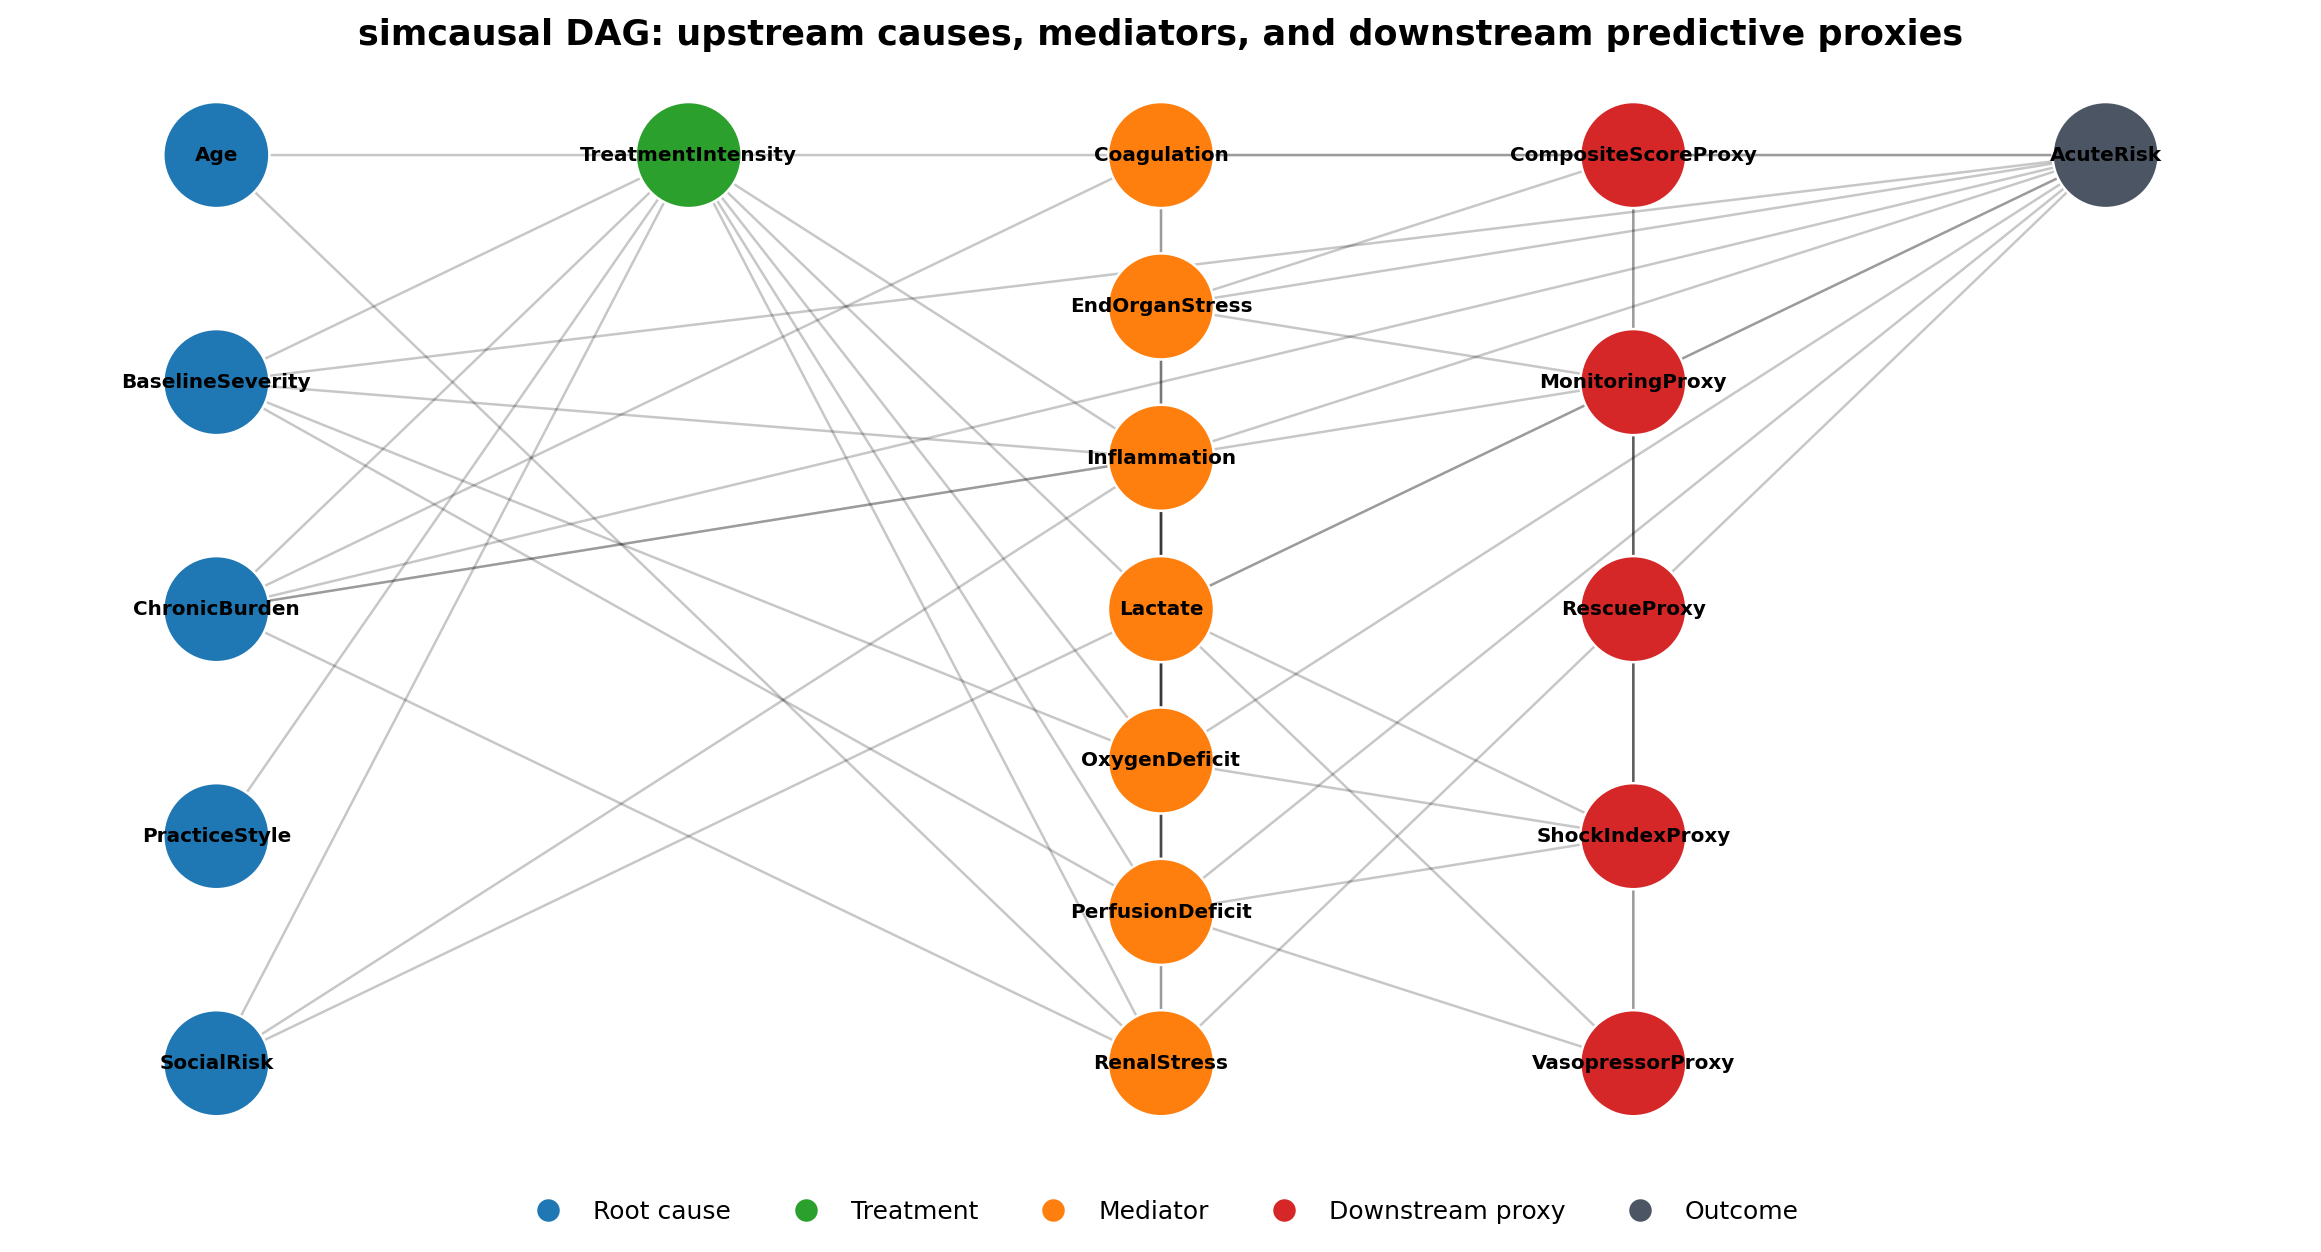

In [7]:
display(Image(filename=str(OUTPUT / "dag_many_mediators.png")))

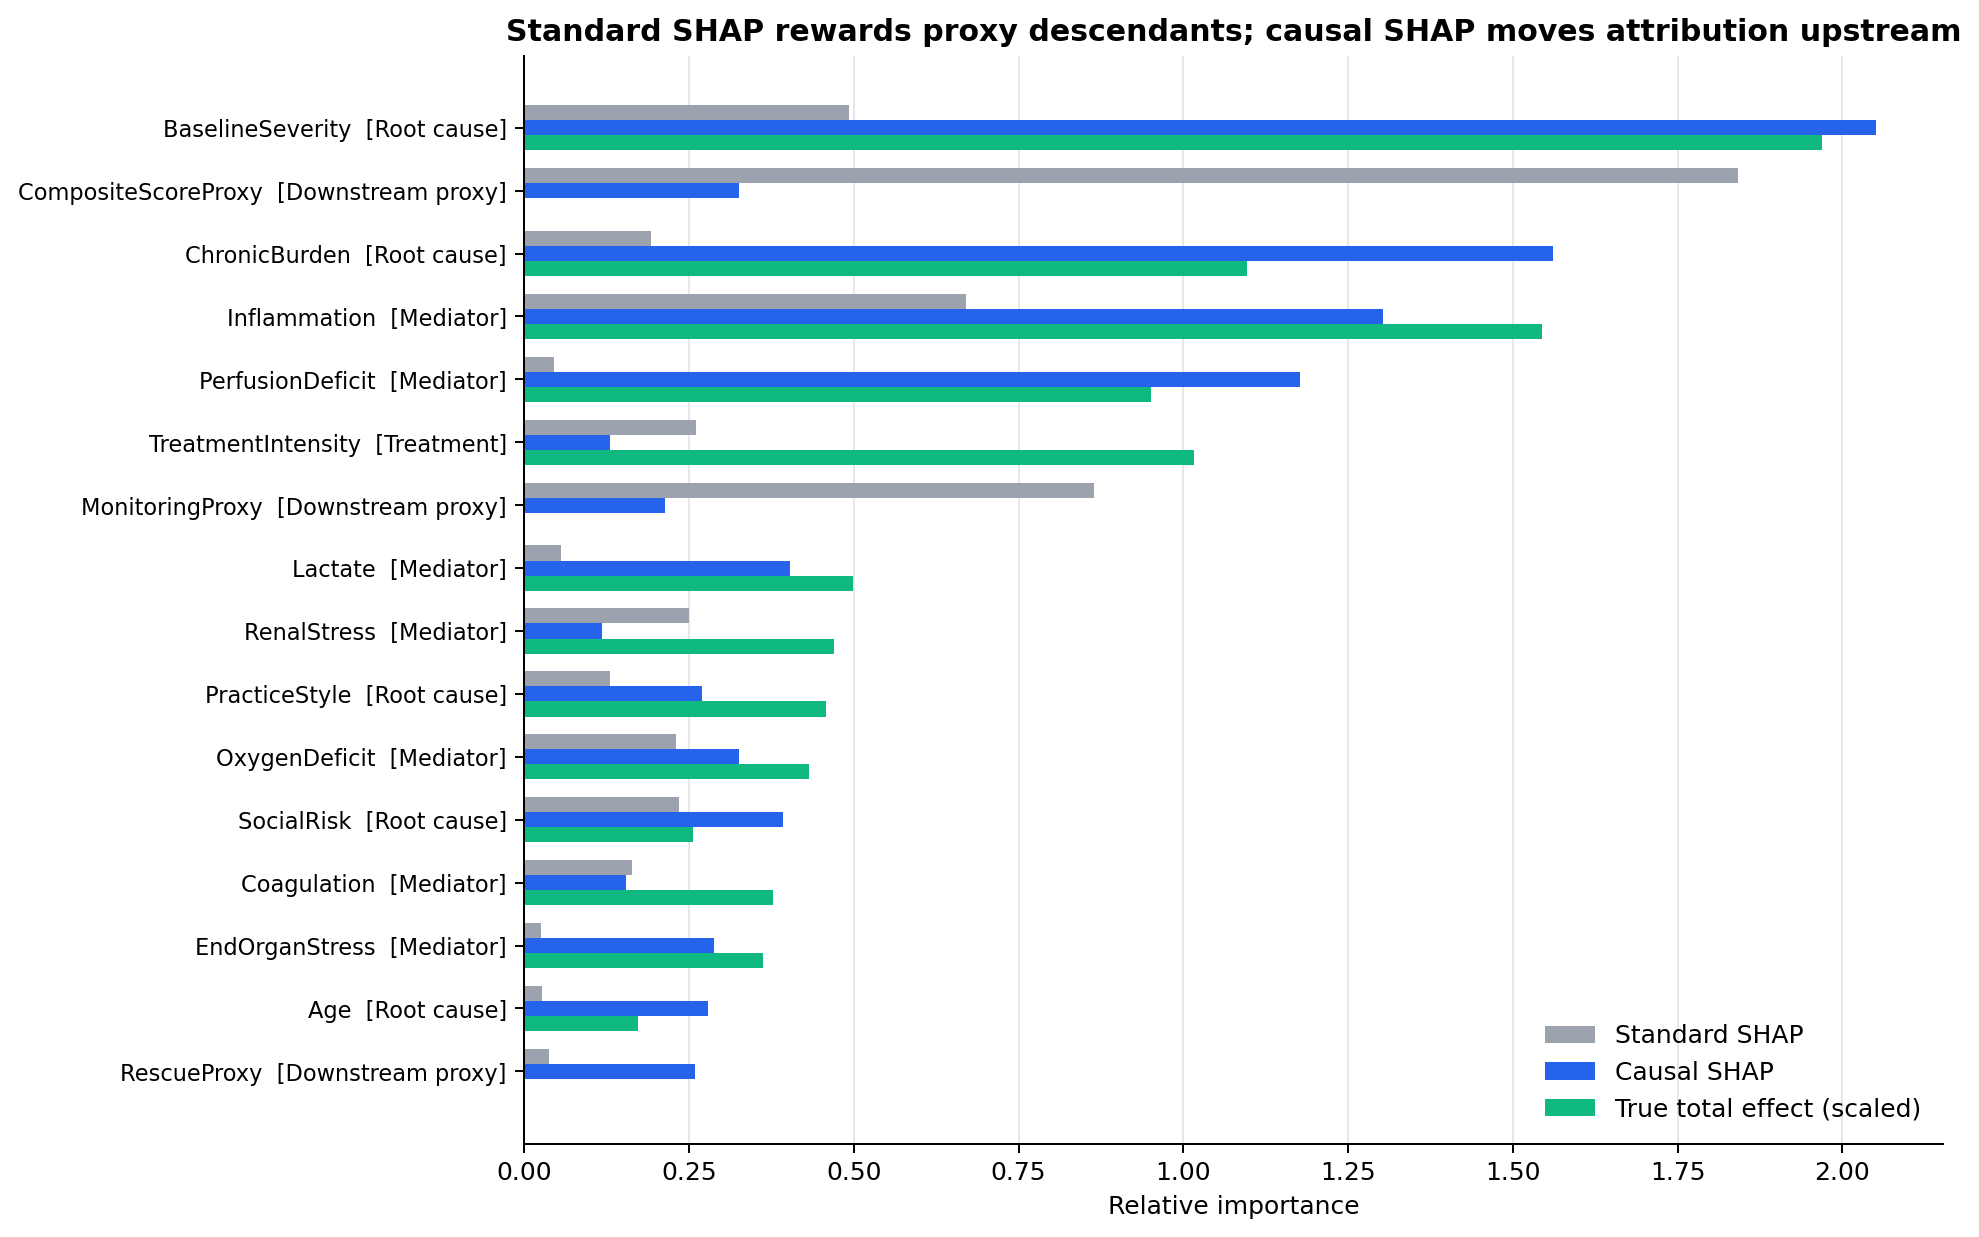

In [8]:
display(Image(filename=str(OUTPUT / "standard_vs_causal_shap.png")))

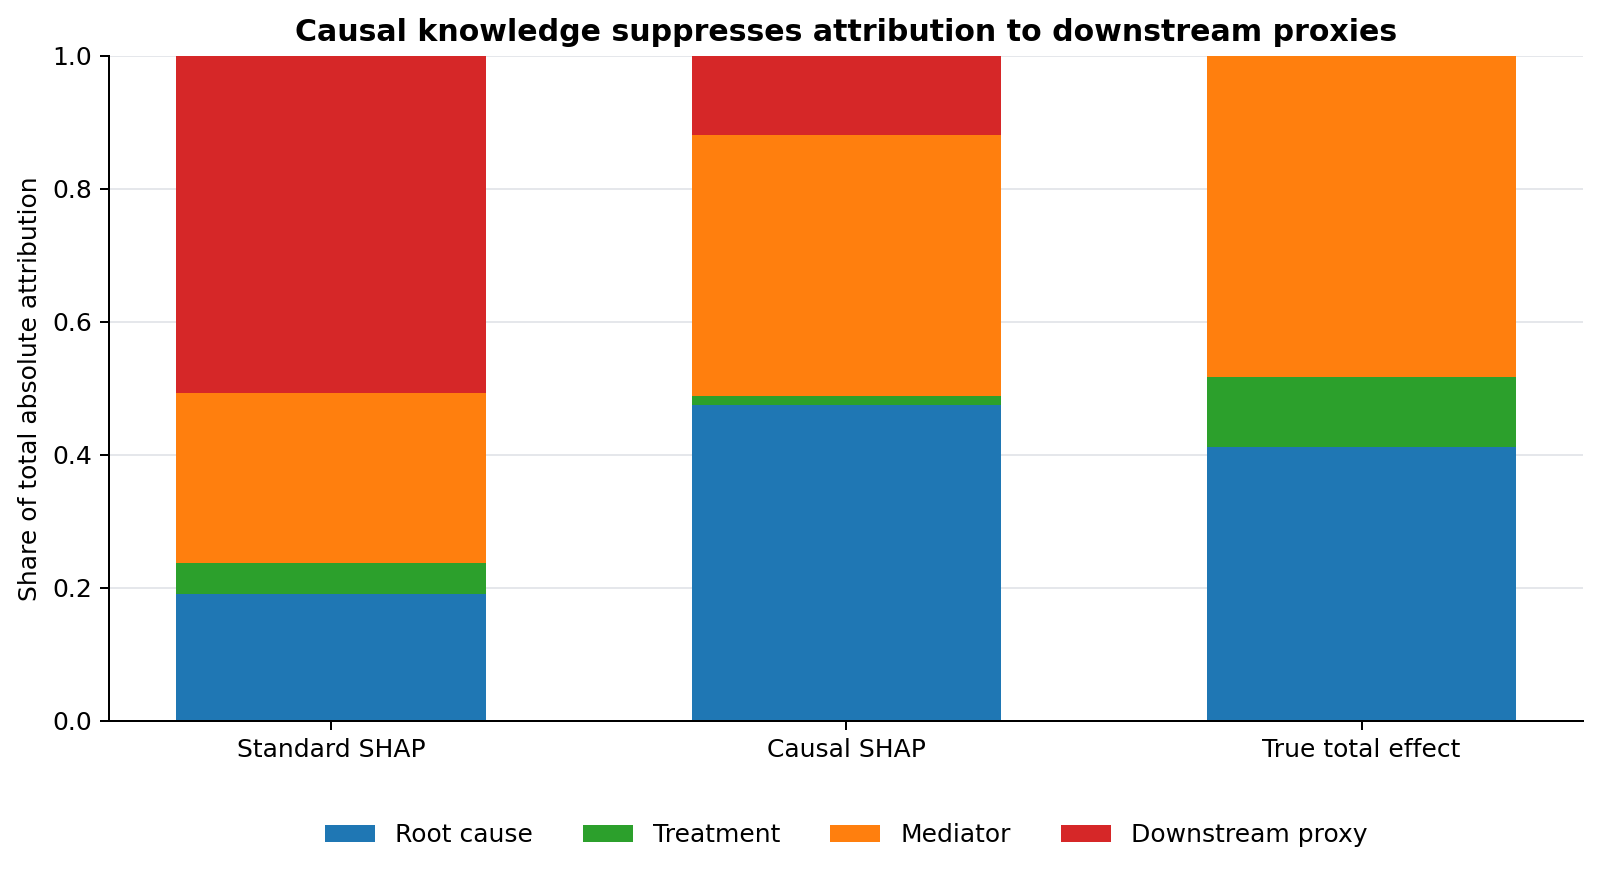

In [9]:
display(Image(filename=str(OUTPUT / "role_attribution_shift.png")))

## Teaching interpretation

The key contrast is not whether the predictive model can predict. It can. The contrast is what each attribution method says the model has learned. Standard SHAP can assign high importance to downstream proxy descendants because they compactly summarize the disease process. Causal SHAP uses the DAG to condition interventions in topological order, so descendant proxies contribute only residual information after their causes have already entered the coalition.